### 1, 2. Limpieza de Datos y Exploración Inicial de Datos

In [1]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(df_train.head())
print("\n\n")
print(df_test.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  




In [2]:
# Guardar PassengerId para uso posterior en la creación del archivo de submission
train_passenger_ids = df_train['PassengerId']
test_passenger_ids = df_test['PassengerId']

# Columnas a eliminar
columns_to_drop = ['PassengerId', 'Name', 'Cabin']

# Eliminar columnas en train y test
df_train.drop(columns=columns_to_drop, inplace=True)
df_test.drop(columns=columns_to_drop, inplace=True)

In [3]:
print(df_train.info())
print("\n\n")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Destination   8511 non-null   object 
 3   Age           8514 non-null   float64
 4   VIP           8490 non-null   object 
 5   RoomService   8512 non-null   float64
 6   FoodCourt     8510 non-null   float64
 7   ShoppingMall  8485 non-null   float64
 8   Spa           8510 non-null   float64
 9   VRDeck        8505 non-null   float64
 10  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(4)
memory usage: 687.8+ KB
None



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    4190 non-null   object 
 1   CryoSleep     4184 non

In [4]:
print(df_train.describe())
print("\n\n")
print(df_test.describe())

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  



               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  4186.000000

In [5]:
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

2266
1065


In [6]:
print("Valores nulos en 'train':")
print(df_train.isnull().sum())
print("\n\n")
print("Valores nulos en 'test':")
print(df_test.isnull().sum())

Valores nulos en 'train':
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
dtype: int64



Valores nulos en 'test':
HomePlanet       87
CryoSleep        93
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
dtype: int64


In [7]:
# Imputar valores nulos en 'train'
# Columnas de gasto
gasto_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Imputar valores nulos y convertir tipos de datos (como lo hicimos antes)
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in categorical_cols:
    df_train[col].fillna(df_train[col].mode()[0], inplace=True)
    df_test[col].fillna(df_train[col].mode()[0], inplace=True)

for col in numeric_cols:
    df_train[col].fillna(df_train[col].median(), inplace=True)
    df_test[col].fillna(df_train[col].median(), inplace=True)

df_train[categorical_cols] = df_train[categorical_cols].astype('category')
df_test[categorical_cols] = df_test[categorical_cols].astype('category')

# Imputar valores de gasto como la mediana de los pasajeros que no estaban en CryoSleep (False) y tienen gasto cero o vacío
# Se hace esto porque se supone que una persona que no duerme obviamente usufructuará estos gastos y viceversa
for col in gasto_cols:
    median_value = df_train.loc[df_train['CryoSleep'] == False, col].median()
    df_train.loc[(df_train['CryoSleep'] == False) & ((df_train[col] == 0) | (df_train[col].isnull())), col] = median_value
    df_test.loc[(df_test['CryoSleep'] == False) & ((df_test[col] == 0) | (df_test[col].isnull())), col] = median_value

# Imputar valores cero en la columna Age con la mediana
df_train['Age'] = df_train['Age'].replace(0, df_train['Age'].median())
df_test['Age'] = df_test['Age'].replace(0, df_train['Age'].median())

# Verificación de los dataframes después de la imputación
print("Verificación de imputaciones en 'train':")
print(df_train[gasto_cols].head())
print("\n\nVerificación de imputaciones en 'test':")
print(df_test[gasto_cols].head())

Verificación de imputaciones en 'train':
   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck
0          1.0        3.0           1.0     5.0     2.0
1        109.0        9.0          25.0   549.0    44.0
2         43.0     3576.0           1.0  6715.0    49.0
3          1.0     1283.0         371.0  3329.0   193.0
4        303.0       70.0         151.0   565.0     2.0


Verificación de imputaciones en 'test':
   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck
0          0.0        0.0           0.0     0.0     0.0
1          1.0        9.0           1.0  2823.0     2.0
2          0.0        0.0           0.0     0.0     0.0
3          1.0     6652.0           1.0   181.0   585.0
4         10.0        3.0         635.0     5.0     2.0


<ipython-input-7-42d5aa719a51>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna(df_train[col].mode()[0], inplace=True)
<ipython-input-7-42d5aa719a51>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [8]:
# Detección de outliers en 'train'
print("Detección de outliers en 'train':")
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

total_outliers_train = 0
total_outliers_test = 0
for column in numeric_cols:
    Q1 = df_train[column].quantile(0.25)
    Q3 = df_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_train = df_train[(df_train[column] < lower_bound) | (df_train[column] > upper_bound)]
    total_outliers_train += len(outliers_train)
    print(f"Outliers en '{column}' = {len(outliers_train)}")

# Detección de outliers en 'test'
print("\n\nDetección de outliers en 'test':")
for column in numeric_cols:
    Q1 = df_test[column].quantile(0.25)
    Q3 = df_test[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_test = df_test[(df_test[column] < lower_bound) | (df_test[column] > upper_bound)]
    total_outliers_test += len(outliers_test)
    print(f"Outliers en '{column}' = {len(outliers_test)}")

print(f"\nTotal de outliers en 'train' = {total_outliers_train}")
print(f"Total de outliers en 'test' = {total_outliers_test}")

Detección de outliers en 'train':
Outliers en 'Age' = 162
Outliers en 'RoomService' = 1906
Outliers en 'FoodCourt' = 1916
Outliers en 'ShoppingMall' = 1879
Outliers en 'Spa' = 1833
Outliers en 'VRDeck' = 1849


Detección de outliers en 'test':
Outliers en 'Age' = 75
Outliers en 'RoomService' = 919
Outliers en 'FoodCourt' = 931
Outliers en 'ShoppingMall' = 912
Outliers en 'Spa' = 921
Outliers en 'VRDeck' = 927

Total de outliers en 'train' = 9545
Total de outliers en 'test' = 4685


### 3. Análisis Exploratorio de Datos (EDA)

EDA con Outliers

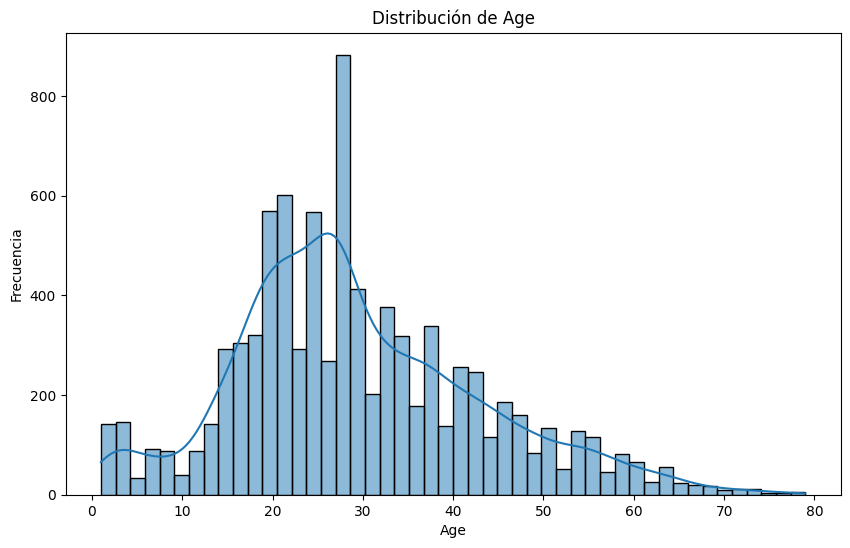

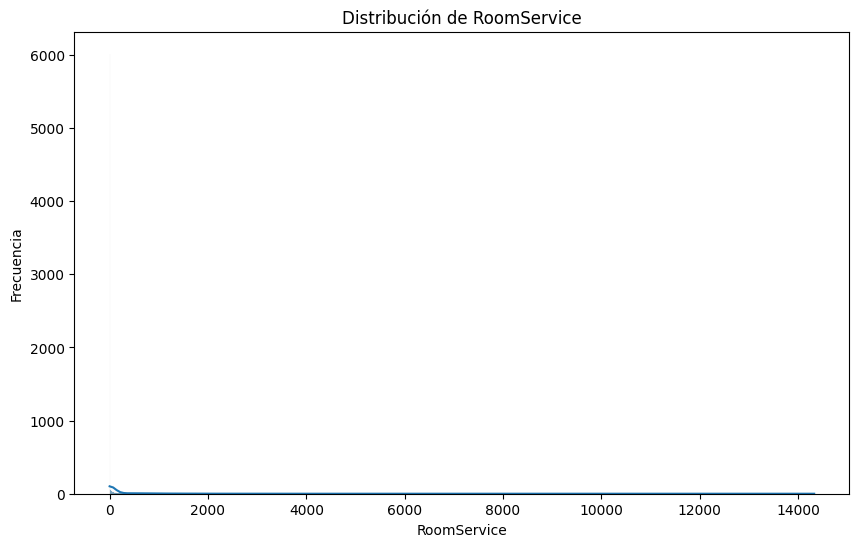

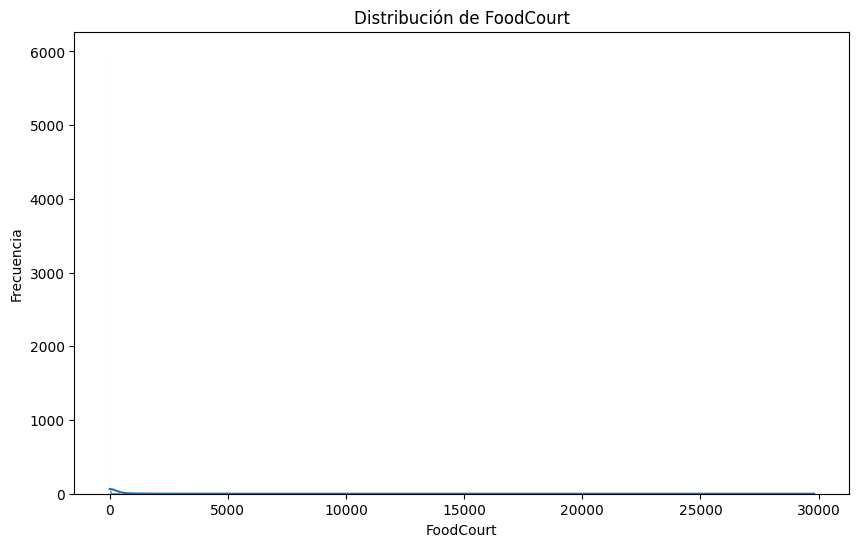

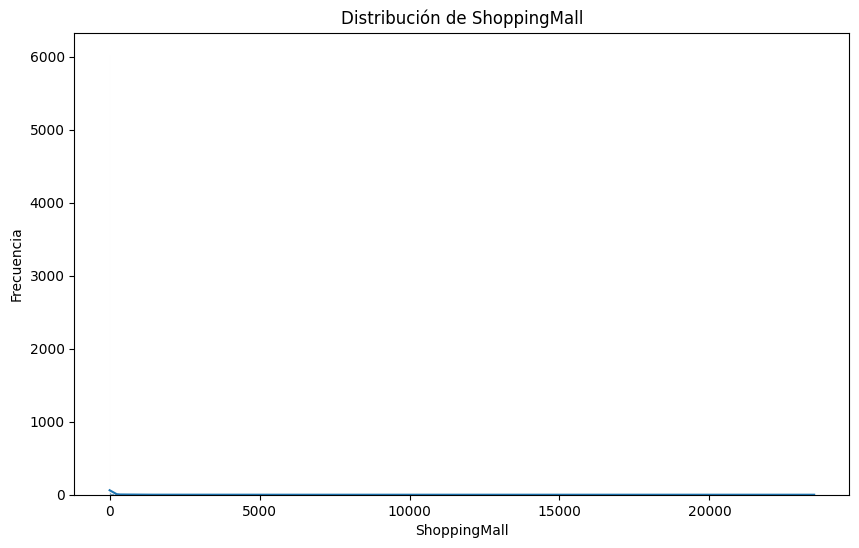

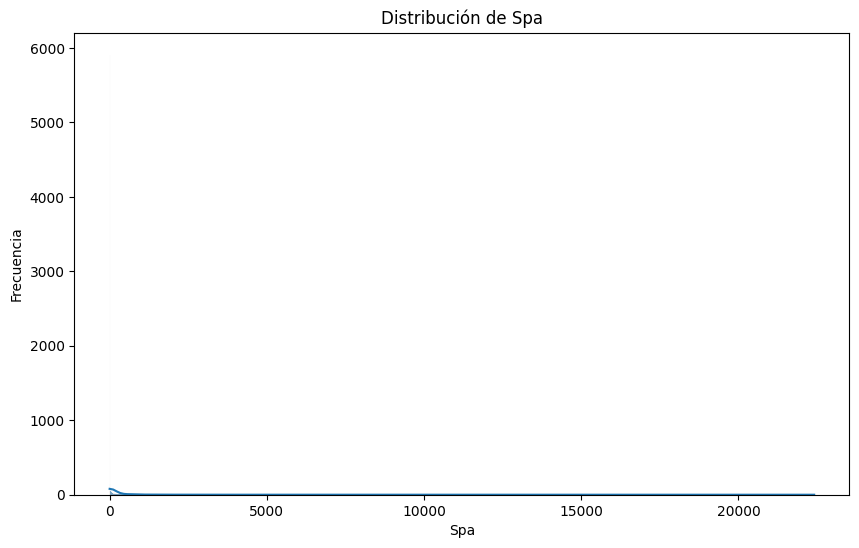

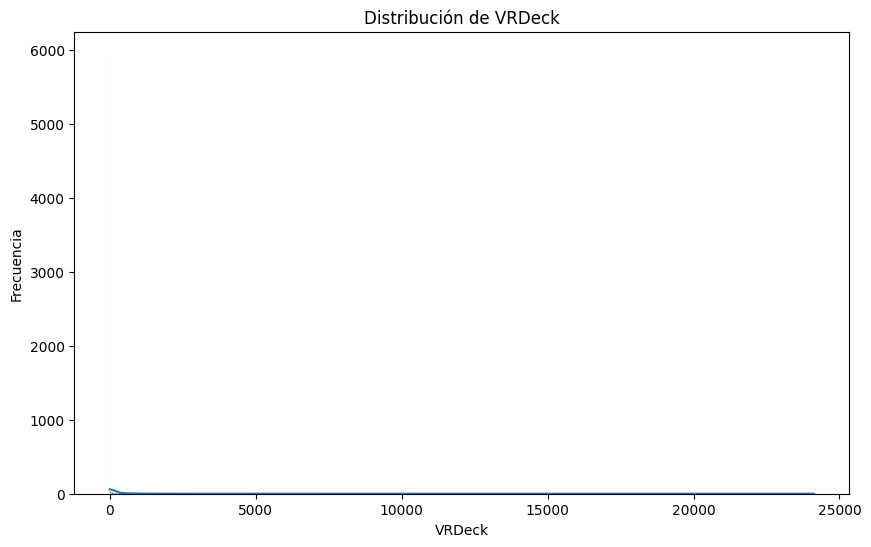

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Histogramas
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_train[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

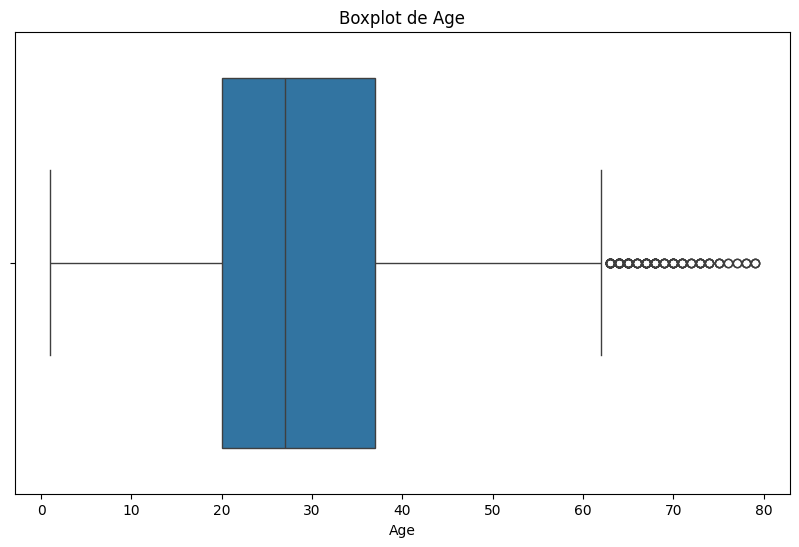

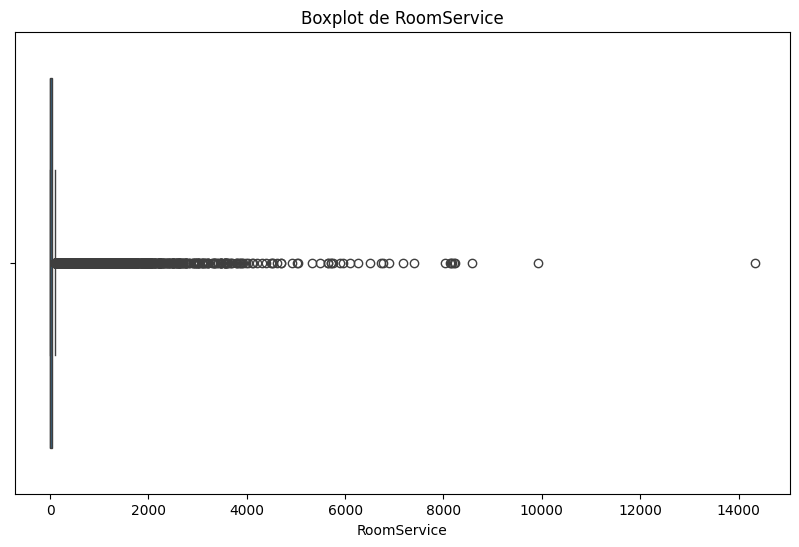

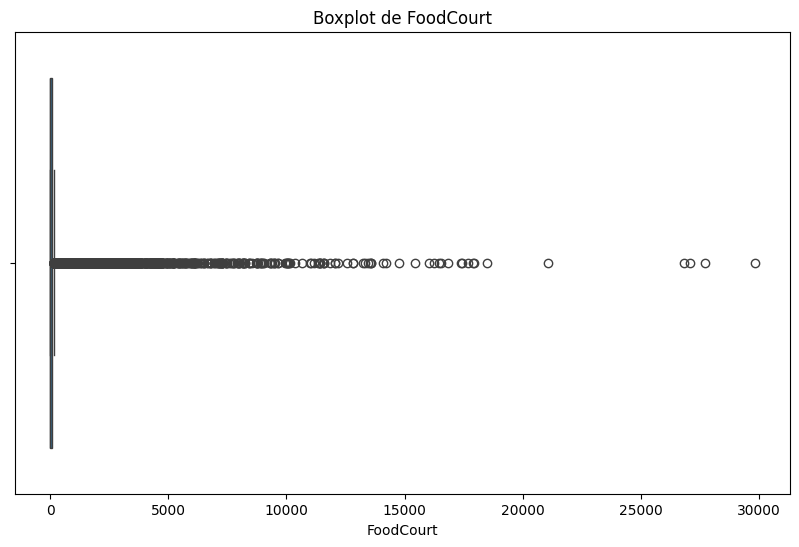

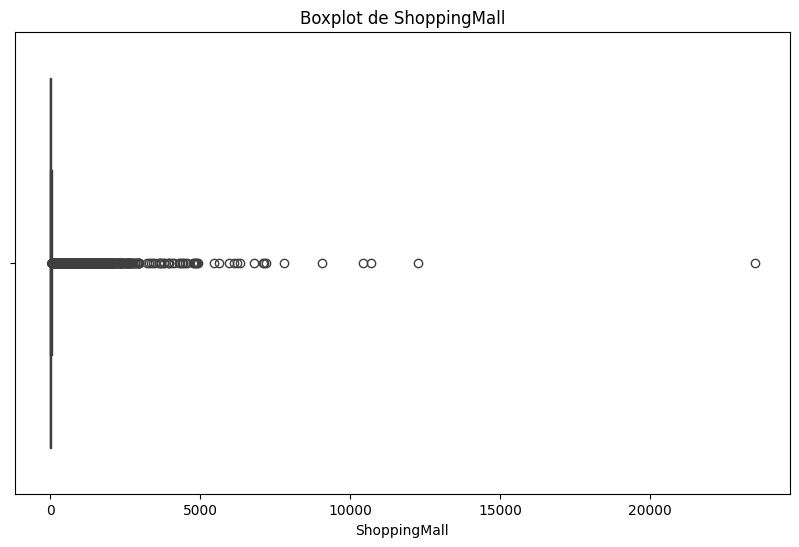

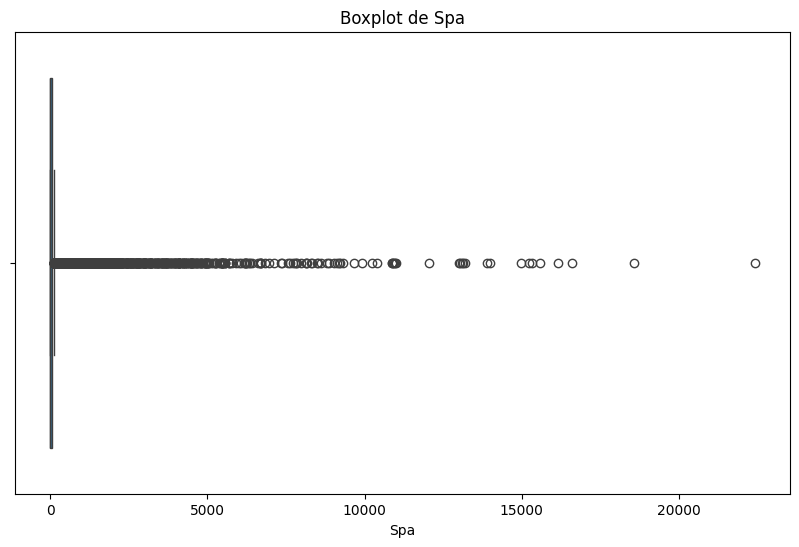

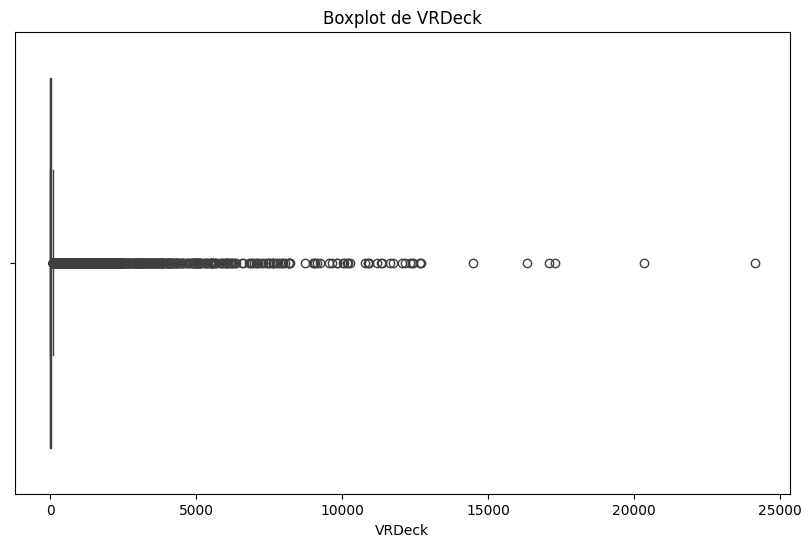

In [20]:
# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_train[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

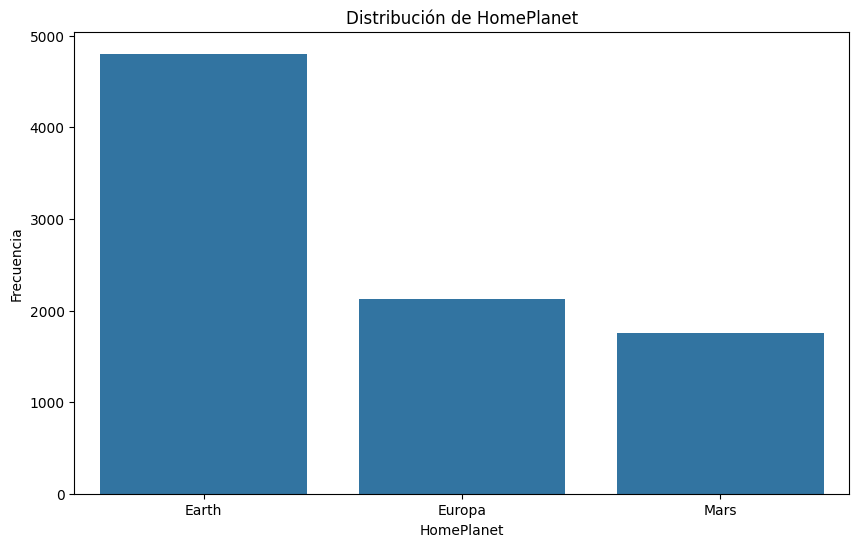

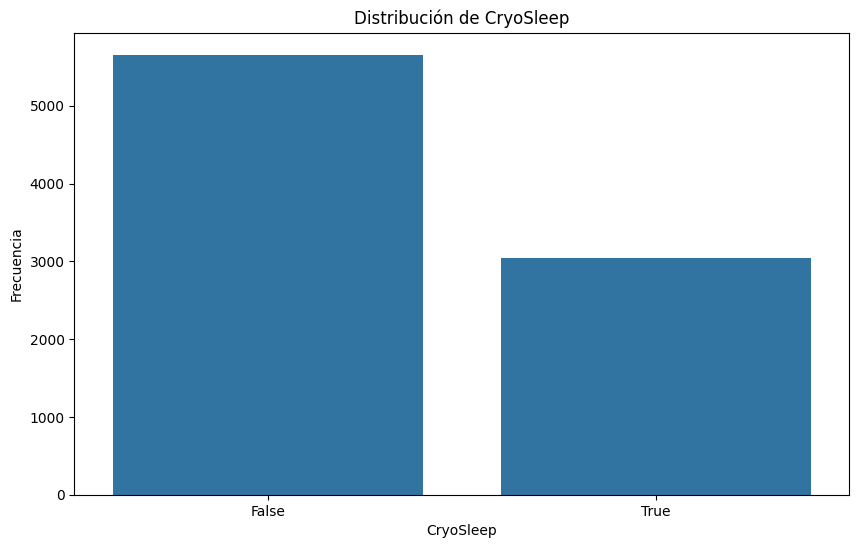

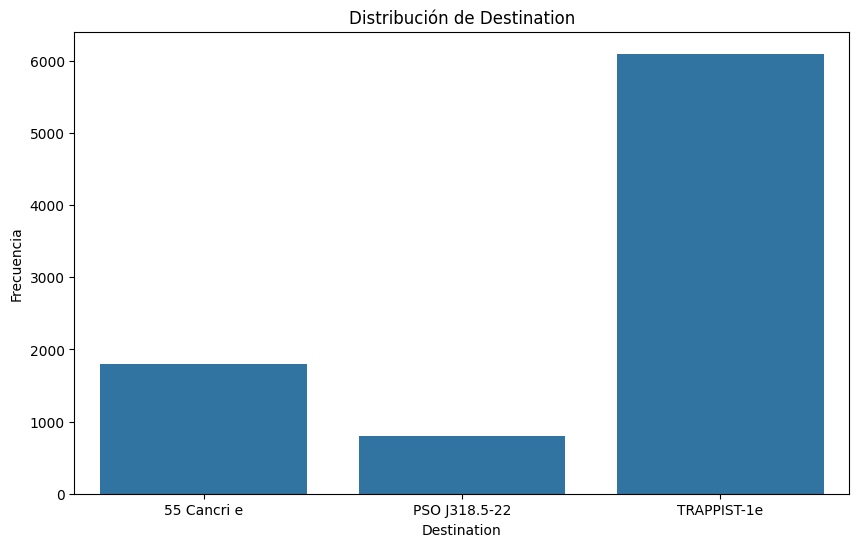

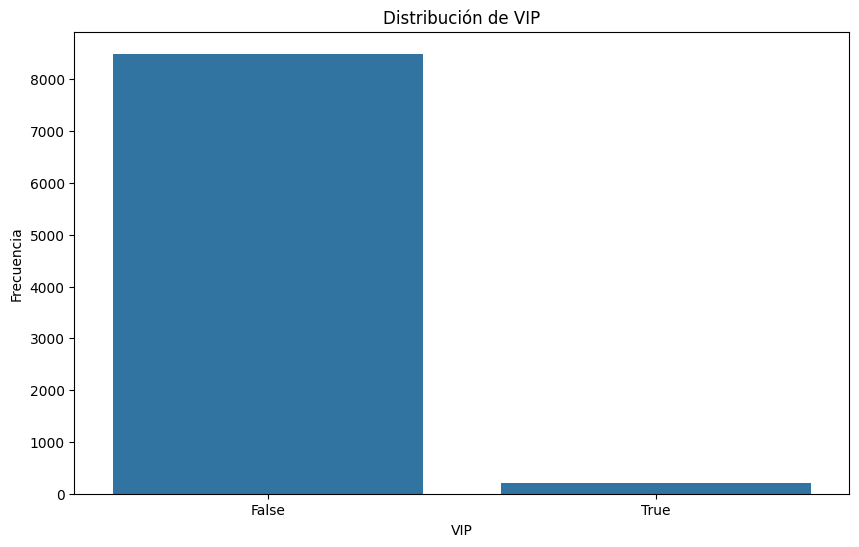

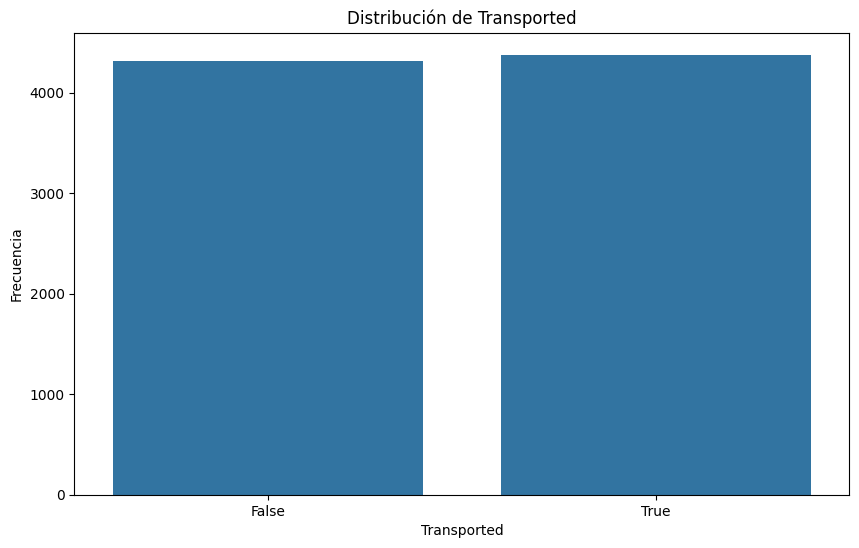

In [21]:
# Variables categóricas
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported']

# Barplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=df_train[col])
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

EDA sin outliers

Matriz de Correlación con Heatmap

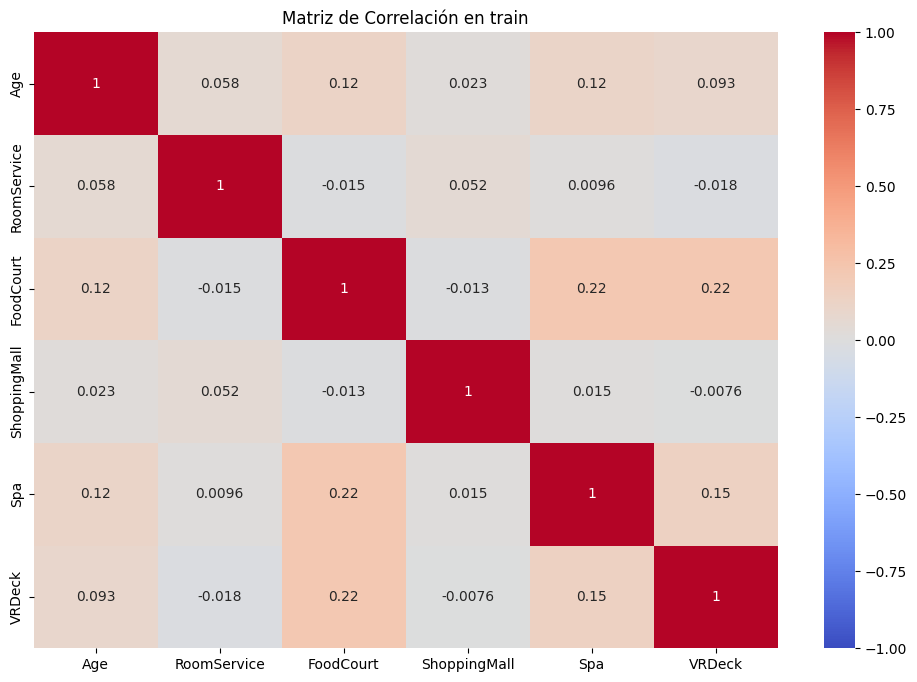

In [22]:
# Calcular la matriz de correlación outliers en 'train'
correlation_matrix = df_train.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación en train')
plt.show()

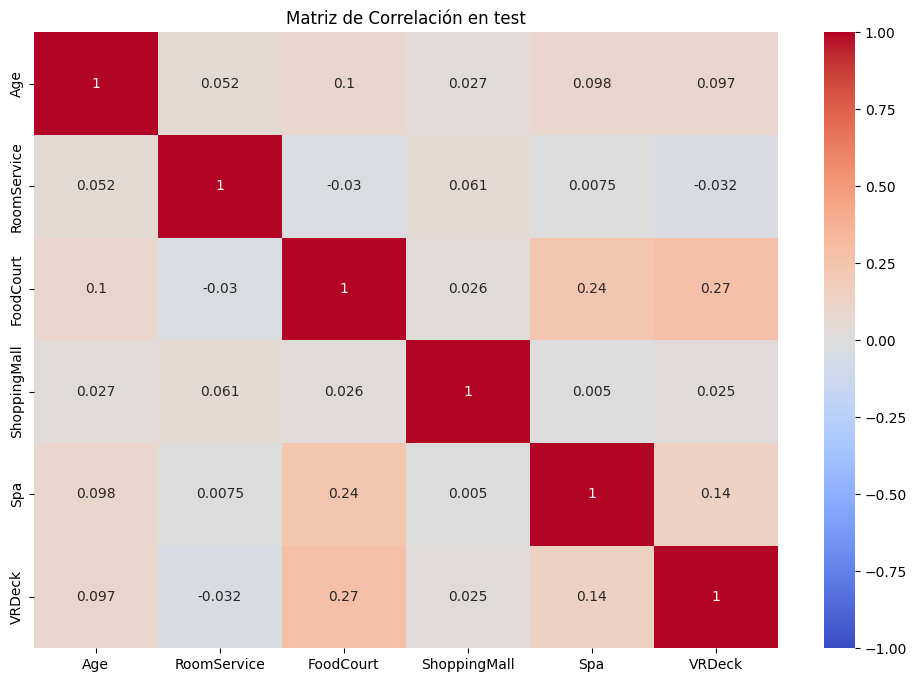

In [23]:
# Calcular la matriz de correlación en 'test'
correlation_matrix = df_test.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación en test')
plt.show()

 ### 4. Preprocesamiento de Datos:

* Transformar las columnas según sea necesario (codificación de variables categóricas, escalado de características numéricas).
* Dividir el dataset en conjuntos de entrenamiento y prueba.

Transformar

In [28]:
# Codificación de variables categóricas
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

def encode_categories(df, encoder=None, fit=False): # Add encoder parameter
    # Ensure all categorical columns are present in the DataFrame
    missing_cols = set(categorical_cols) - set(df.columns)
    if missing_cols:
        for col in missing_cols:
            df[col] = 0  # or any suitable default value

    # Store 'Transported' column if present
    transported_col = df['Transported'] if 'Transported' in df.columns else None

    # Initialize the OneHotEncoder only if encoder is None
    if encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for dense output

    if fit:
        encoded = encoder.fit_transform(df[categorical_cols])
    else:
        encoded = encoder.transform(df[categorical_cols])

    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
    df = df.drop(categorical_cols, axis=1)
    df = pd.concat([df, encoded_df], axis=1)

    # Agregar columna 'Transported' de vuelta si está presente
    if transported_col is not None:
        df['Transported'] = transported_col

    return df, encoder # Return the encoder

# Entrenar el encoder unicamente en el train
df_train_encoded, encoder = encode_categories(df_train, fit=True) # Get the fitted encoder
df_test_encoded, _ = encode_categories(df_test, encoder=encoder) # Pass the fitted encoder to transform test data

Division de conjuntos

In [29]:
# División de conjuntos
if 'Transported' in df_train_encoded.columns:
    X_train = df_train_encoded.drop('Transported', axis=1)
else:
    print("Column 'Transported' not found in DataFrame. Check if it was dropped earlier or if the name is correct.")
    # Handle the case appropriately, e.g., assign X_train to df_train_encoded if the column is not present.
    X_train = df_train_encoded

y_train = df_train_encoded['Transported']

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [30]:
# Verificación y manejo de valores nulos antes del escalado
def check_and_impute_na(df):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col].fillna(median_value, inplace=True)
    return df

df_train_encoded = check_and_impute_na(df_train_encoded)

print("Valores nulos en X_train_split antes del escalado:")
print(X_train_split.isnull().sum().sum())

print("\nValores nulos en X_val_split antes del escalado:")
print(X_val_split.isnull().sum().sum())

Valores nulos en X_train_split antes del escalado:
0

Valores nulos en X_val_split antes del escalado:
0


Escalar

In [31]:
import numpy as np
# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)

# Verificar y manejar valores NaN después del escalado
def check_and_impute_na_after_scaling(scaled_array, original_df):
    df_scaled = pd.DataFrame(scaled_array, columns=original_df.columns)
    for col in df_scaled.columns:
        if df_scaled[col].isnull().sum() > 0:
            median_value = df_scaled[col].median()
            df_scaled[col].fillna(median_value, inplace=True)
    return df_scaled.values

X_train_scaled = check_and_impute_na_after_scaling(X_train_scaled, X_train_split)
X_val_scaled = check_and_impute_na_after_scaling(X_val_scaled, X_val_split)

# Verificación final de valores nulos
print("Verificación final de valores nulos en todos los conjuntos después del escalado:")
print("X_train_scaled:", np.isnan(X_train_scaled).sum())
print("X_val_scaled:", np.isnan(X_val_scaled).sum())

Verificación final de valores nulos en todos los conjuntos después del escalado:
X_train_scaled: 0
X_val_scaled: 0


### 5. Implementación de Modelos y Benchmark:

* Entrenar y evaluar al menos cinco modelos diferentes, como Regresión Logística, K-Nearest Neighbors (KNN), Árbol de Decisión, XGBoost y LightGBM.
* Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.
* Optimizar los hiperparámetros de los modelos seleccionados utilizando GridSearchCV o RandomizedSearchCV.
* Comparar el rendimiento de los modelos utilizando métricas adecuadas.

Regresión Logística

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Modelo de Regresión Logística
log_reg = LogisticRegression(max_iter=5000, random_state=42, solver='saga')
log_reg_scores = cross_val_score(log_reg, X_train_scaled, y_train_split, cv=5, error_score='raise')

print(f"Regresión Logística:\n\t* Precisión media: {log_reg_scores.mean()}\n\t* Desviación estándar: {log_reg_scores.std()}")

Regresión Logística:
	* Precisión media: 1.0
	* Desviación estándar: 0.0


K-Nearest Neighbors (KNN)

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Modelo KNN
knn = KNeighborsClassifier()
knn_scores = cross_val_score(knn, X_train_scaled, y_train_split, cv=5)
print(f"KNN:\n\t* Precisión media: {knn_scores.mean()}\n\t* Desviación estándar: {knn_scores.std()}")

KNN:
	* Precisión media: 0.997555611872831
	* Desviación estándar: 0.0013332404931679052


Árbol de decisión

In [34]:
from sklearn.tree import DecisionTreeClassifier

# Modelo de Árbol de Decisión
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree_scores = cross_val_score(decision_tree, X_train_scaled, y_train_split, cv=5)
print(f"Árbol de Decisión:\n\t* Precisión media: {decision_tree_scores.mean()}\n\t* Desviación estándar: {decision_tree_scores.std()}")

Árbol de Decisión:
	* Precisión media: 1.0
	* Desviación estándar: 0.0


XGBoost

In [35]:
from xgboost import XGBClassifier

# Modelo XGBoost
xgb = XGBClassifier(random_state=42)
xgb_scores = cross_val_score(xgb, X_train_scaled, y_train_split, cv=5)
print(f"XGBoost:\n\t* Precisión media: {xgb_scores.mean()}\n\t* Desviación estándar: {xgb_scores.std()}")

XGBoost:
	* Precisión media: 1.0
	* Desviación estándar: 0.0


LightGBM

Exactitud: 1.0
Informe de Clasificación:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       861
        True       1.00      1.00      1.00       878

    accuracy                           1.00      1739
   macro avg       1.00      1.00      1.00      1739
weighted avg       1.00      1.00      1.00      1739

Matriz de Confusión:
[[861   0]
 [  0 878]]


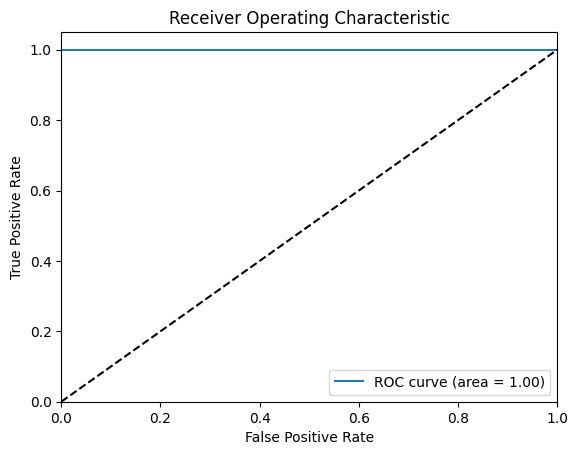

In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Crear el modelo SVM con un kernel lineal
model = SVC(kernel='linear', probability=True, random_state=42)

# Entrenar el modelo
model.fit(X_train_split, y_train_split)

# Realizar predicciones en el conjunto de validación
y_pred = model.predict(X_val_split)
y_prob = model.predict_proba(X_val_split)[:, 1]

# Evaluar el modelo
accuracy = accuracy_score(y_val_split, y_pred)
print(f'Exactitud: {accuracy}')
print('Informe de Clasificación:')
print(classification_report(y_val_split, y_pred))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_val_split, y_pred)
print('Matriz de Confusión:')
print(conf_matrix)

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_val_split, y_prob)
auc = roc_auc_score(y_val_split, y_prob)

# Plotear la curva ROC
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


Optimización de Hiperparámetros con GridSearchCV

In [38]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Definir un espacio de hiperparámetros reducido
param_grid = {
    'num_leaves': [31, 50],
    'min_child_samples': [10, 20],
    'max_depth': [5, 10],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 500]
}

# Configurar GridSearchCV
grid_search = GridSearchCV(estimator=LGBMClassifier(random_state=42), param_grid=param_grid, scoring='accuracy', cv=5, n_jobs=-1)

# Ejecutar GridSearchCV
grid_search.fit(X_train_split, y_train_split)

# Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3500, number of negative: 3454
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1377
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503307 -> initscore=0.013230
[LightGBM] [Info] Start training from score 0.013230
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

Evaluación del Mejor Modelo de GridSearchCV

Exactitud del mejor modelo: 1.0
Informe de Clasificación:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       861
        True       1.00      1.00      1.00       878

    accuracy                           1.00      1739
   macro avg       1.00      1.00      1.00      1739
weighted avg       1.00      1.00      1.00      1739

Matriz de Confusión:
[[861   0]
 [  0 878]]


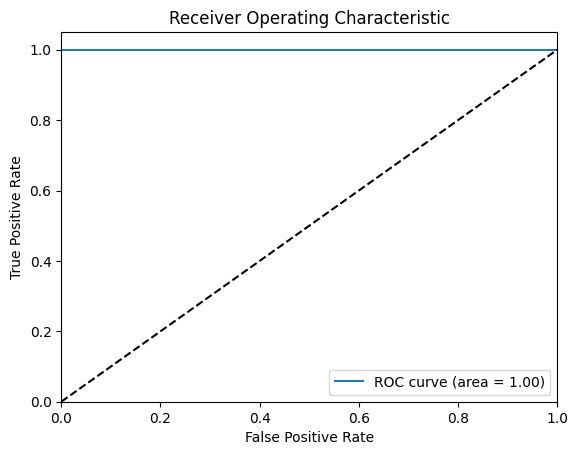

In [40]:
# Evaluar el mejor modelo en el conjunto de validación
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val_split)
y_prob = best_model.predict_proba(X_val_split)[:, 1]

# Evaluar el modelo
accuracy = accuracy_score(y_val_split, y_pred)
print(f'Exactitud del mejor modelo: {accuracy}')
print('Informe de Clasificación:')
print(classification_report(y_val_split, y_pred))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_val_split, y_pred)
print('Matriz de Confusión:')
print(conf_matrix)

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_val_split, y_prob)
auc = roc_auc_score(y_val_split, y_prob)

# Plotear la curva ROC
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
